In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
# Load Preprocessed Data
X_train = pd.read_csv("data/X_train_scaled.csv")
X_test = pd.read_csv("data/X_test_scaled.csv")

y_train = pd.read_csv("data/y_train.csv").values.ravel()
y_test = pd.read_csv("data/y_test.csv").values.ravel()

In [3]:
pca = PCA(n_components=10)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [4]:
results = []

In [5]:
# Logistic Regression Model without PCA
lr = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [6]:
# Evaluate Logistic Regression
results.append({
    'Model': 'Logistic Regression',
    'Data': 'Scaled',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
})

In [7]:
# Confusion Matrix
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression Confusion Matrix:
[[41  2]
 [ 1 70]]


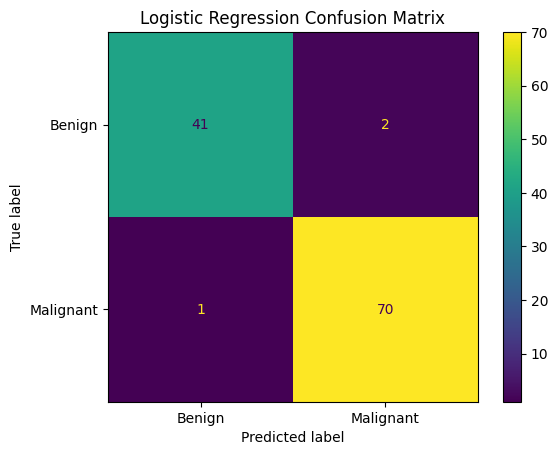

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [9]:
# Logistic Regression Model with PCA
lr_pca = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)

lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)


In [10]:
# Evaluate Logistic Regression
results.append({
    'Model': 'Logistic Regression',
    'Data': 'PCA',
    'Accuracy': accuracy_score(y_test, y_pred_pca),
    'Precision': precision_score(y_test, y_pred_pca),
    'Recall': recall_score(y_test, y_pred_pca),
    'F1 Score': f1_score(y_test, y_pred_pca)
})

In [11]:
# Classification Report
print("Logistic Regression (Scaled)")
print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))

print("Logistic Regression (PCA)")
print(classification_report(y_test, y_pred_pca, target_names=["Malignant", "Benign"]))

Logistic Regression (Scaled)
              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        43
      Benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Logistic Regression (PCA)
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        43
      Benign       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Random Forest Model

In [12]:
# Random Forest (Without PCA)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [13]:
# Evaluate Random Forest
results.append({
    'Model': 'Random Forest',
    'Data': 'Scaled',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
})

In [14]:
# Confusion Matrix
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Random Forest Confusion Matrix:
[[40  3]
 [ 1 70]]


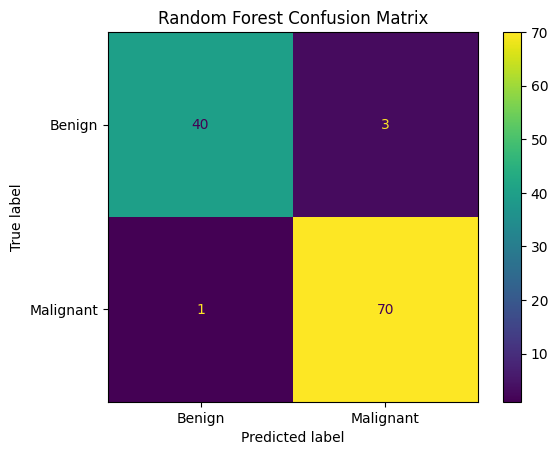

In [15]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [16]:
# Random Forest (WITH PCA)
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)

rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)

In [17]:
# Evaluate Random Forest
results.append({
    'Model': 'Random Forest',
    'Data': 'PCA',
    'Accuracy': accuracy_score(y_test, y_pred_pca),
    'Precision': precision_score(y_test, y_pred_pca),
    'Recall': recall_score(y_test, y_pred_pca),
    'F1 Score': f1_score(y_test, y_pred_pca)
})

In [18]:
# Classification Report
print("Random Forest (Scaled)")
print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))

print("Random Forest (PCA)")
print(classification_report(y_test, y_pred_pca, target_names=["Malignant", "Benign"]))

Random Forest (Scaled)
              precision    recall  f1-score   support

   Malignant       0.98      0.93      0.95        43
      Benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Random Forest (PCA)
              precision    recall  f1-score   support

   Malignant       0.93      0.95      0.94        43
      Benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [19]:
# Convert Results to Table
results_df = pd.DataFrame(results)
print(results_df)

                 Model    Data  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  Scaled  0.973684   0.972222  0.985915  0.979021
1  Logistic Regression     PCA  0.982456   0.985915  0.985915  0.985915
2        Random Forest  Scaled  0.964912   0.958904  0.985915  0.972222
3        Random Forest     PCA  0.956140   0.971429  0.957746  0.964539


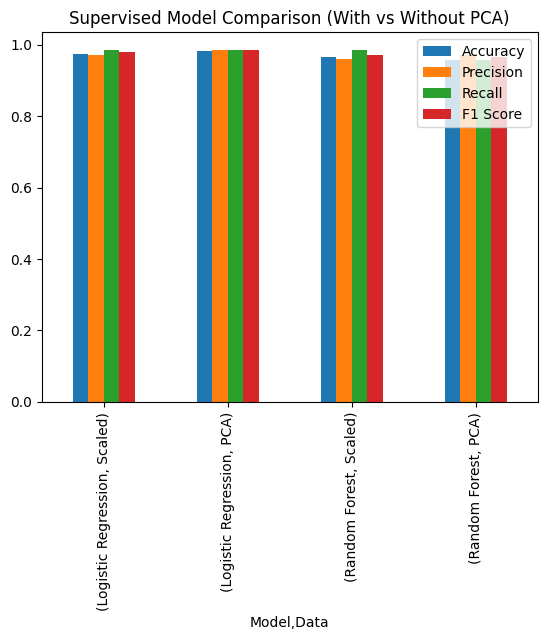

In [20]:
results_df.set_index(['Model','Data'])[['Accuracy','Precision','Recall','F1 Score']].plot(kind='bar')
plt.title("Supervised Model Comparison (With vs Without PCA)")
plt.show()